# Simulando Vida com Partículas
*Projeto final de PCD (Prática em Ciências de Dados)*

## Introdução
... a preencher

## 1. Base do jogo

Vamos começar definindo a base do nosso jogo, utilizando a biblioteca *Pygame*.

Nesse caso, estou utilizando a versão `pygame-ce 2.5.7 (SDL 2.32.10, Python 3.13.7)`

In [244]:
# Importando bibliotecas
import pygame

In [245]:
# Código base ajustado de http://pygametutorials.wikidot.com/tutorials-basic

class Game:
    def __init__(self, width = 700, height = 700, max_fps = 60):
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps
    
    def on_init(self):
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True
    
    def on_event(self, event):
        if event.type == pygame.QUIT:
            self.running = False
    
    def on_loop(self):
        pass

    def on_render(self):
        pass

    def on_cleanup(self):
        pygame.quit()

    def on_execute(self):
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

In [246]:
game = Game()
game.on_execute()

## 2. Partículas

Vamos começar definindo nossas partículas. Cada partícula terá três características:
- espécie
- posição
- velocidade

In [247]:
class Particle:
    def __init__(self, species, position = [0, 0], velocity = [0,0]):
        self.species = species
        self.position = position
        self.velocity = velocity
    
    def on_render(self, surface): 
        pygame.draw.circle(surface, self.species.color, self.position, self.species.size)
    

A espécie da partícula é responsável por definir sua cor, seu tamanho e as interações com os demais tipos. Por enquanto, vamos deixar as interações de lado.

In [248]:
class Species:
    def __init__(self, id, color, size = 1):
        self.id = id
        self.color = color
        self.size = size

Vamos atualizar a classe de jogo para conseguir receber as partículas

In [249]:
class Game:
    def __init__(self, width = 700, height = 700, max_fps = 60):
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps

        # Lista de partículas
        self.particles = []
    
    def on_init(self):
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True

    def on_add_particle(self, particle):
        self.particles.append(particle)
    
    def on_event(self, event):
        if event.type == pygame.QUIT:
            self.running = False
    
    def on_loop(self):
        pass

    def on_render(self):
        # Limpa a tela
        self.display.fill((20, 20, 20))

        # Renderiza as partículas
        for particle in self.particles:
            particle.on_render(self.display)

        pygame.display.flip()

    def on_cleanup(self):
        pygame.quit()

    def on_execute(self):
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Agora basta criarmos algumas partículas e iniciar o jogo

In [250]:
game = Game()

red_species = Species(0, (255,0,0), 4)

game.on_add_particle(Particle(red_species, [100, 200]))
game.on_add_particle(Particle(red_species, [200, 600]))
game.on_add_particle(Particle(red_species, [450, 30]))
game.on_add_particle(Particle(red_species, [320, 460]))

game.on_execute()

Mas adicionar cada partícula manualmente não é eficiente, por isso criaremos uma função responsável por adicionar n partículas aleatórias na tela

In [251]:
# Importando a biblioteca de aleatoriedade
import random

In [252]:
def instantiate_particles(number_of_particles, species, game):
    for i in range(number_of_particles):
        particle_species = random.choice(species)
        particle_x = random.randint(0, game.width)
        particle_y = random.randint(0, game.height)
        
        new_particle = Particle(particle_species, [particle_x, particle_y])
        game.on_add_particle(new_particle)

In [253]:
game = Game()

red_species = Species(0, (255,0,0), 4)
species = [red_species]

instantiate_particles(500, species, game)

game.on_execute()

## 3. Interações
Agora que já temos as partículas, precisamos fazer elas interagirem entre si.

Para isso, criaremos uma função de força baseada na distância normalizada entre duas partículas. Por enquanto, vamos fazer que essa força atue linearmente até uma certa distância, atraindo partículas próximas umas das outras.

In [254]:
# Importando bibliotecas de operações matemáticas e de construção de gráficos
import math
import numpy as np
from matplotlib import pyplot as plt

In [255]:
def force_function(dist, attraction):
    if 0 <= dist <= 1:
        return dist * attraction

    return 0

In [256]:
# Função suporte para plotagem de gráficos
def plot_function(function, start, end, resolution, *args):
    x = np.linspace(start, end, resolution)
    y = [function(xi, *args) for xi in x]

    plt.plot(x, y)
    plt.title(function.__name__)
    plt.show()

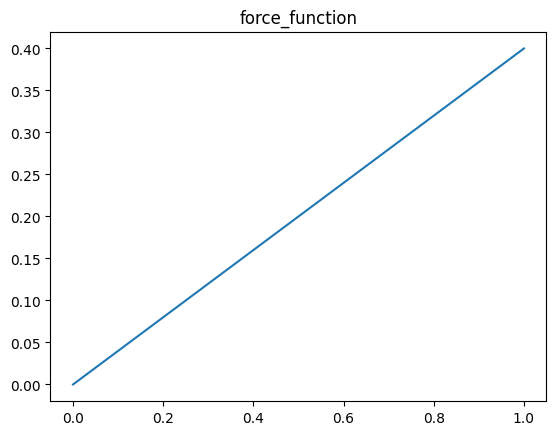

In [257]:
plot_function(force_function, 0, 1, 1000, 0.4)

Vamos criar também uma matriz de interações, responsável por ditar a interaçao de cada spécie uma com a outra.
Cada interação guarda 2 valores: atração e visão.

Como só temos uma espécia, vamos ter apenas um tipo de interação (dela com ela mesma).

In [258]:
interactions = [
    [(0.2, 100)]
]

Também definiremos uma constante de atrito, para restringir o movimento das nossas partículas

In [259]:
friction = 0.3

Com a função de força definia, podemos implementá-la nas nossas partículas.

In [260]:
class Particle:
    def __init__(self, species, position = None, velocity = None):
        self.species = species
        self.position = position
        if self.position == None:
            self.position = [0, 0]

        self.new_position = position.copy()
        self.velocity = velocity
        if self.velocity == None:
            self.velocity = [0, 0]
    
    def on_render(self, surface): 
        pygame.draw.circle(surface, self.species.color, self.position, self.species.size)
    
    def on_loop(self, particles, force_function, interactions, friction):
        force_x = 0
        force_y = 0

        for other_particle in particles:
            if other_particle.position == self.position:
                continue
        
            attraction, vision = interactions[self.species.id][other_particle.species.id]

            diff_x = other_particle.position[0] - self.position[0]
            diff_y = other_particle.position[1] - self.position[1]

            if abs(diff_x) >= vision or abs(diff_y) >= vision:
                continue

            distance = math.sqrt(diff_x ** 2 + diff_y ** 2)

            if distance > vision or distance <= 0:
                continue

            normal_distance = distance / vision

            force = force_function(normal_distance, attraction)

            force_x += force * (diff_x / distance)
            force_y += force * (diff_y / distance)

            # print(distance, diff_x, diff_y)
        
        self.velocity[0] += force_x
        self.velocity[1] += force_y

        self.new_position[0] += self.velocity[0]
        self.new_position[1] += self.velocity[1]

        self.velocity[0] *= 1 - friction
        if abs(self.velocity[0]) < 0.1:
            self.velocity[0] = 0
            
        self.velocity[1] *= 1 - friction
        if abs(self.velocity[1]) < 0.1:
            self.velocity[1] = 0

    def update_position(self):
        self.position = self.new_position

Agora, implementamos no jogo a atualização das partículas.

In [261]:
class Game:
    def __init__(self, interactions, force_function, friction, width = 700, height = 700, max_fps = 60):
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps
        self.particles = []

        self.interactions = interactions
        self.force_function = force_function
        self.friction = friction
    
    def on_init(self):
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True

    def on_add_particle(self, particle):
        self.particles.append(particle)
    
    def on_event(self, event):
        if event.type == pygame.QUIT:
            self.running = False
    
    def on_loop(self):
        # Atualiza as partículas
        for particle in self.particles:            
            particle.on_loop(self.particles, self.force_function, self.interactions, self.friction)
        
        for particle in self.particles:    
            particle.update_position()

    def on_render(self):
        self.display.fill((20, 20, 20))

        for particle in self.particles:
            particle.on_render(self.display)

        pygame.display.flip()

    def on_cleanup(self):
        pygame.quit()

    def on_execute(self):
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Rodando o jogo, temos:

In [262]:
game = Game(interactions, force_function, friction)

red_species = Species(0, (255,0,0), 4)
species = [red_species]

instantiate_particles(300, species, game)

game.on_execute()

Como o esperado, as partículas apenas se atraem entre si, pois não apresentam nenhuma força de repulsão. Podemos alterar isso modificando a função de força para incluir uma repulsão em distâncias muito próximas, e uma força que seja proporcional à distância.

In [263]:
def force_function(dist, attraction):
    repulsion_intensity = -0.8
    repulsion_radius = 0.3

    if 0 <= dist < repulsion_radius:
        return dist * (-repulsion_intensity / repulsion_radius) + repulsion_intensity

    mid = repulsion_radius + ((1 - repulsion_radius) / 2)

    if repulsion_radius <= dist < mid:
        return (dist - repulsion_radius) * attraction / (mid - repulsion_radius)

    if mid <= dist <= 1:
        return -(1 - dist) * (-attraction / (1 - mid))

    return 0

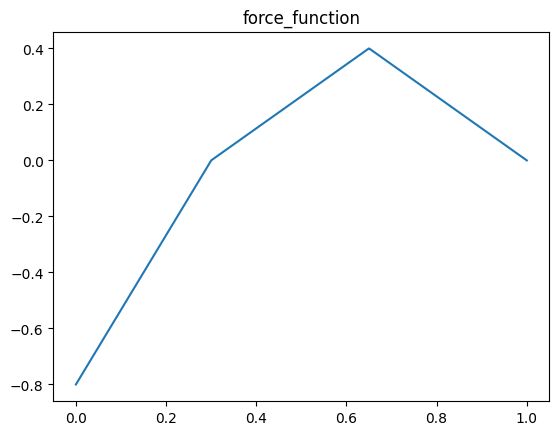

In [264]:
plot_function(force_function, -0, 1, 1000, 0.4)

In [265]:
game = Game(interactions, force_function, friction)

red_species = Species(0, (255,0,0), 4)
species = [red_species]

instantiate_particles(300, species, game)

game.on_execute()

Se eu definir que as partículas terão apenas interações de repulsão, elas tentam se distribuir na tela

In [266]:
red_species = Species(0, (255,0,0), 4)
species = [red_species]

interactions = [
    [(-0.5, 100)]
]

game = Game(interactions, force_function, friction)

instantiate_particles(300, species, game)

game.on_execute()

Agora podemos criar uma espécie azul, que se afasta da vermelha

In [267]:
red_species = Species(0, (255,0,0), 4)
blue_species = Species(1, (0, 0, 255), 4)
species = [red_species, blue_species]

interactions = [
    [(0.2, 100), (0.6, 100)],    # Vermelho com Vermelho | Vermelho com Azul
    [(-0.2, 100), (0.2, 100)],   # Azul com Vermelho     | Azul com Azul
]

game = Game(interactions, force_function, friction)

instantiate_particles(300, species, game)

game.on_execute()

Note que mesmo com duas partículas em um sistema tão simples quanto esse, já começam a aparecer estruturas aparentemente complexas - algumas estacionárias e outras em movimento.

<img alt="célula" src="../imagens/jupyter_notebook/celula.jpg" width="100px"><br/>
Estrutura de "Célula"<br/>
<br/>
<img alt="nave" src="../imagens/jupyter_notebook/nave.jpg" width="100px"><br/>
Estrutra de "Nave"<br/>

Agora podemos adicionar uma terceira espécie:

In [268]:
red_species = Species(0, (255,0,0), 4)
blue_species = Species(1, (0, 0, 255), 4)
yellow_species = Species(2, (255, 255, 0), 4)
species = [red_species, blue_species, yellow_species]

interactions = [
    [(0.3, 100), (-0.2, 100), (0.2, 100)],   # Vermelho com Vermelho | Vermelho com Azul | Vermelho com Amarelo
    [(0.3, 100), (0.3, 100), (-0.1, 100)],   # Azul com Vermelho     | Azul com Azul     | Azul com Amarelo
    [(-0.2, 100), (0.3, 100), (0.3, 100)],   # Amarelo com Vermelho  | Amarelo com Azul  | Amarelo com Amarelo
]

game = Game(interactions, force_function, friction)

instantiate_particles(300, species, game)

game.on_execute()

Com três espécies, já é possível montar estruturas rotatórias. Entretanto, a performance atual do nosso código não é das melhores, pois, para cada partícula, estamos conferindo todas as outras partículas, mesmo aquelas que estão muito distantes, com uma complexidade de aproximadamente $O(n^2)$. Isso pode ser resolvido se reescrevermos nossa lógica com vetores do numpy no lugar de um modelo orientado a objeto. Como no caderno simulando_vida_com_particulas_performance.ipynb

In [269]:
class Game:
    def __init__(self, interactions, force_function, friction, species, particle_number = 300, width = 700, height = 700, max_fps = 60, dt = 1):
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps
        self.dt = dt

        self.interactions = interactions
        self.force_function = force_function
        self.friction = friction
        self.species = species
        self.particle_number = particle_number

        ### Informações das partículas
        self.particles = self.initiate_particles()
        

        self.interactions_matrix = self.interactions[
            self.particles["species"][:, None],
            self.particles["species"][None, :]
        ]

        self.interactions_strength = self.interactions_matrix[:, :, 0]
        self.interactions_radius = self.interactions_matrix[:, :, 1]

    def initiate_particles(self):
        particles = {}
        particles["positions"] = np.random.rand(self.particle_number, 2) * [self.width, self.height]
        particles["velocities"] = np.zeros((self.particle_number, 2))
        particles["species"] = np.random.randint(0, len(self.species), size=self.particle_number)

        return particles

    def on_init(self):
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True

    def on_event(self, event):
        if event.type == pygame.QUIT:
            self.running = False

    def on_loop(self):
        #Atualiza as partículas
        diff = self.particles["positions"][None, :, :] - self.particles["positions"][:, None, :]
        dist = dist = np.linalg.norm(diff, axis=2) + 1e-5 # Soma um número muito pequeno pra não dividir por 0 depois

        np.fill_diagonal(dist, np.inf) # Evita forças com a própria partícula

        direction = diff / dist[:, :, None]

        dist /= self.interactions_radius # Normaliza a distância com base na visão

        force_strength = self.force_function(dist, self.interactions_strength)
        force_strength[dist > 1] = 0

        force = force_strength[:, :, None] * direction

        total_force = np.sum(force, axis=1)

        self.particles["velocities"] = (self.particles["velocities"] + total_force * self.dt) * (1 - self.friction)

        self.particles["positions"] += self.particles["velocities"] * self.dt
        # self.particles["positions"] %= [self.width, self.height]


    def on_render(self):
        self.display.fill((20, 20, 20))

        for i in range(len(self.particles["positions"])):
            pos = self.particles["positions"][i]
            species = self.species[self.particles["species"][i]]
            pygame.draw.circle(self.display, species.color, pos, species.size)

        pygame.display.flip()

    def on_cleanup(self):
        pygame.quit()

    def on_execute(self):
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Agora vamos atualizar a `force_function` para receber a matriz de distancias

In [270]:
def force_function(dist, attraction):
    repulsion_intensity = -0.8
    repulsion_radius = 0.3

    force = np.zeros_like(dist)

    mask_1 = (0 <= dist) & (dist < repulsion_radius)
    force[mask_1] = (
        dist[mask_1] * (-repulsion_intensity / repulsion_radius) + repulsion_intensity
    )

    mid = repulsion_radius + ((1 - repulsion_radius) / 2)

    mask_2 = (repulsion_radius <= dist) & (dist < mid)
    force[mask_2] = (
        (dist[mask_2] - repulsion_radius) * attraction[mask_2] / (mid - repulsion_radius)
    )

    mask_3 = (mid <= dist) & (dist <= 1)
    force[mask_3] = (
        -(1 - dist[mask_3]) * (-attraction[mask_3] / (1 - mid))
    )

    return force

In [271]:
red_species = Species(0, (255,0,0), 2)
blue_species = Species(1, (0, 0, 255), 2)
yellow_species = Species(2, (255, 255, 0), 2)
species = [red_species, blue_species, yellow_species]

interactions = np.array([
    [(0.3, 100), (-0.2, 100), (0.2, 100)],   # Vermelho com Vermelho | Vermelho com Azul | Vermelho com Amarelo
    [(0.3, 100), (0.3, 100), (-0.1, 100)],   # Azul com Vermelho     | Azul com Azul     | Azul com Amarelo
    [(-0.2, 100), (0.3, 100), (0.3, 100)],   # Amarelo com Vermelho  | Amarelo com Azul  | Amarelo com Amarelo
])

game = Game(interactions, force_function, friction, species, particle_number=600)

game.on_execute()

Agora vamos testar com mais espécies

In [274]:
red_species = Species(0, (255, 0, 0), 4)
blue_species = Species(1, (0, 0, 255), 4)
yellow_species = Species(2, (255, 255, 0), 4)
green_species = Species(3, (0, 255, 0), 4)
purple_species = Species(4, (255, 0, 255), 4)
cyan_species = Species(5, (0, 255, 255), 4)
white_species = Species(6, (255, 255, 255), 4)

species = [
    red_species, blue_species, yellow_species,
    green_species, purple_species, cyan_species, white_species
]

interactions = np.array([

    # R         B           Y          G           P           C          W
    [(0.3,100), (-0.2,100), (0.2,100), (-0.1,100), (0.4,100), (0.0,100), (-0.3,100)],  # RED
    [(0.3,100), (0.3,100), (-0.1,100), (0.2,100), (-0.4,100), (0.1,100), (0.0,100)],   # BLUE
    [(-0.2,100), (0.3,100), (0.3,100), (-0.3,100), (0.0,100), (0.2,100), (0.1,100)],   # YELLOW
    [(0.1,100), (-0.2,100), (0.3,100), (0.3,100), (0.2,100), (-0.3,100), (0.0,100)],   # GREEN
    [(0.4,100), (0.1,100), (-0.2,100), (0.3,100), (0.3,100), (-0.1,100), (0.2,100)],   # PURPLE
    [(0.0,100), (-0.3,100), (0.2,100), (0.1,100), (0.3,100), (0.3,100), (-0.2,100)],   # CYAN
    [(-0.3,100), (0.0,100), (0.1,100), (-0.2,100), (0.2,100), (0.3,100), (0.3,100)]    # WHITE

])

game = Game(interactions, force_function, friction, species, particle_number=600, width=800, height=800)

game.on_execute()

## Referências

https://docs.python.org/3/

http://pygametutorials.wikidot.com/tutorials-basic

https://matplotlib.org/stable/index.html

https://numpy.org/doc/stable/

https://www.pygame.org/docs/

https://www.nature.com/articles/srep37969

https://www.youtube.com/watch?v=2vt4MBxcOhs

https://www.ventrella.com/Clusters/intro.html

https://www.youtube.com/watch?v=p4YirERTVF0

https://www.youtube.com/watch?v=scvuli-zcRc

https://www.youtube.com/watch?v=0HqUYpGQIfs

https://www.youtube.com/watch?v=4vk7YvBYpOs